## Decision Tree from Scratch

In [ ]:
#Imports
import numpy as np
import pandas as pandas
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [ ]:
#makemoons Dataset
#=====================================================
#make_moons() creates an artificial (synthetic) dataset.
#      ● ● ● ●
#    ●         ●
#   ●           ●

#        ○ ○ ○ ○
#      ○         ○
#     ○           ○
#One moon belongs to Class 0, and the other belongs to Class 1.

# The function returns two things.

# X = The input features. It is a NumPy array.

# X = [[1.20, 0.53],
#     [0.11, 0.87],
#     [2.31,-0.45],
#     ...]
# Each row is one data point.
# Each point has 2 features:
# x-coordinate
# y-coordinate

# So, X.shape would give (300, 2)
# Meaning = 300 samples. 2 features each

# y = These are the labels. Example : y = [0,0,1,1,0,1,...]

# There is one label for every point.
# 0 = first moon
# 1 = second moon


In [6]:
#dataset
#150 in 1st class and 150 in 2nd class, some noise so that not a perfect moon
X,y = make_moons(n_samples=300,noise=0.25,random_state=42)
m = 300
#divide the data in train and test 
shuffle = np.random.permutation(m)

X = X[shuffle]
y = y[shuffle]

split = int(0.8*m)

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]


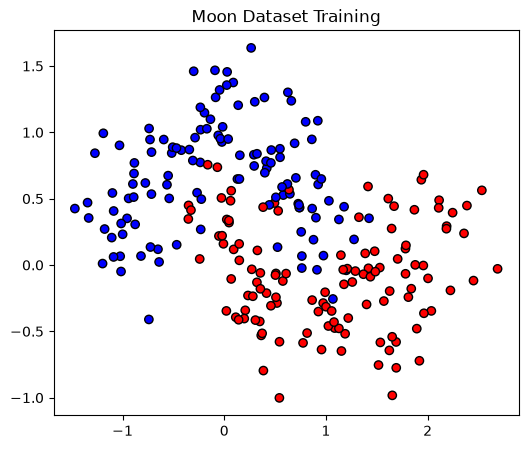

In [10]:
#Visualize dataset
plt.figure(figsize=(6,5))
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap='bwr',edgecolors='k')
plt.title("Moon Dataset Training")
plt.show()


========================
##  Decision Tree
========================

In [83]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [84]:
def gini(y):
    """
    np.unique will give output classes, and count of the classes
    count   class
     4        A
     6        C
     2        E
    And the prob = [4/12, 6/12, 2/12]
    returns = 1 - ∑ (4/12)^2 + (6/12)^2 + (2/12)^2
    """
    if len(y)==0:
        return 0
    classes, counts =np.unique(y,return_counts=True)
    prob = counts/len(y)
    return 1-np.sum(prob**2)

def entropy(y):
    if len(y)==0:
        return 0
    classes, counts = np.unique(y,return_counts=True)
    prob = counts/len(y)
    return -np.sum(prob * np.log2(prob+1e-9))

In [ ]:
def best_split(X,y,criteria='gini'):
    """
    Gain will tell which is the best split.
    gain = impurity before split(parent) - impurit after split
    parent gini = just send the whole column y to gigi function
    take every feature, and each for feature class, calculate gini of y.

    """
    N, d = X.shape
    if len(np.unique(y))==1:
        return None
    
    best_gain = 0
    best_spilt_info = None
    if criteria == 'gini':
        parent_impurity = gini(y)
    else:
        parent_impurity = entropy(y)
    
    for feature in range(d): #No. of columns => select a column 
        thresholds = np.unique(X[:,feature]) #array of the unique values in that column
        for threshold in thresholds: # for every number in that column
            left_mask = X[:,feature] <= threshold #True if the value in that column is <= th
            right_mask = X[:,feature] > threshold #True if the value in that column is > th
            # these above are left and right indices, such that, left <= th < right

            #if True values are 0 in left/right, then threshold is not useful
            if np.sum(left_mask) == 0 or np.sum(right_mask)==0:
                continue

            y_left = y[left_mask] #It contains the y values for threshold dependent indices
            y_right = y[right_mask]

            #calculate impurity of left/right after the split
            if criteria=='gini':
                left_impurity = gini(y_left) 
                right_impurity = gini(y_right)
            else:
                left_impurity = entropy(y_left)
                right_impurity = entropy(y_right)

            #weighted impurity
            N_left = len(y_left)
            N_right = len(y_right)
            weighted_impurity = (N_left/N)*left_impurity + (N_right/N)* right_impurity

            #gain
            gain = parent_impurity - weighted_impurity


            if gain > best_gain:
                best_gain = gain
                best_spilt_info = {
                    'feature' : feature, #column
                    'threshold': threshold,
                    'gain':gain,
                    'left_y':y_left,
                    'right_y': y_right,
                    'left_indices': left_mask,
                    'right_indices': right_mask
                }
    return best_spilt_info


In [91]:
def build_tree(X,y,criteria='gini',max_depth=None,depth=0):
    """ 
    Recursively build Tree. 
    if max_depth given, build tree to that and if None, grow until pure.
    """

    #if all labels are same or max_depth reached
    if len(np.unique(y))==1 or (max_depth is not None and depth >= max_depth):
        unique, counts = np.unique(y,return_counts=True)
        return Node(value = unique[np.argmax(counts)]) #Leaf node with value = class with maxx counts
    #np.argmax = returns maxm count index, Node(value = 1)


    #best split
    split_info = best_split(X,y,criteria)

    if split_info is None or split_info['gain'] <= 1e-9:
        unique, counts = np.unique(y, return_counts=True)
        return Node(value= unique[np.argmax(counts)])

    #split the data -left and right to recursively 
    left_mask = split_info['left_indices']
    right_mask = split_info['right_indices']
    X_left = X[left_mask]
    X_right = X[right_mask]
    y_left = y[left_mask]
    y_right = y[right_mask]

    #Recursively build children
    left_child = build_tree(X_left,y_left,criteria,max_depth, depth+1)
    right_child = build_tree(X_right,y_right,criteria,max_depth,depth+1)

    return Node(
        feature=split_info['feature'],
        threshold=split_info['threshold'],
        left=left_child,
        right=right_child
    )

In [92]:
def predict_tree(node, X):
    """Predict the class of each sample in X"""

    #The output(Prediction).This is the leaf node and leaf node's value = class is the output.
    if node.value is not None:
        return np.full(X.shape[0],node.value) #np.full = array with X's no. of sample size and o/p = value
    
    #if node.value = None, it's not leaf node, the go to left/right node
    left_mask = X[:,node.feature] <= node.threshold #check the condition of this node
    right_mask = ~ left_mask #Logical NOT (~), remaining of left comes here

    #array of sample size to put output
    y_pred = np.zeros(X.shape[0], dtype=int)
    if np.any(left_mask): #if any True samples (<=threshold) in left
        y_pred[left_mask] = predict_tree(node.left, X[left_mask])
    if np.any(right_mask):
        y_pred[right_mask] = predict_tree(node.right, X[right_mask])

    return y_pred


In [93]:
class DecisionTree:
    def __init__(self, criteria='gini', max_depth=None):
        self.criteria = criteria
        self.max_depth = max_depth
        self.root = None

    def fit(self,X,y):
        self.root = build_tree(X,y,self.criteria, self.max_depth)

    def predict(self, X):
        return predict_tree(self.root,X)
    
    def score(self, X,y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [ ]:
x_min, x_max = X_train[:,0].min() - 0.5, X_train[:,0].max()+0.5
y_min, y_max = X_train[:,1].min() - 0.5, X_train[:,1].max()+0.5
xx,yy = np.meshgrid(np.linspace(x_min,x_max,200), np.linspace(y_min, y_max))
grid = np.c_[xx.ravel(),yy.ravel()]

depths = [1,5,20]
trees = {}
for d in depths:
    tree = DecisionTree(criteria='gini', max_depth=d)
    tree.fit(X_train,y_train)
    trees[d] = tree
    print(f"Depth {d}: Train Acc = {tree.score(X_train, y_train):.3f}, Test Acc = {tree.score(X_test, y_test):.3f}")

# Plot decision boundaries
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, d in zip(axes, depths):
    tree = trees[d]
    # Predict on the grid
    Z = tree.predict(grid)
    Z = Z.reshape(xx.shape)
    
    # Plot contour
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr', levels=2)
    # Plot training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', edgecolors='k', s=30)
    ax.set_title(f"max_depth = {d}\nTrain Acc = {tree.score(X_train, y_train):.2f} | Test Acc = {tree.score(X_test, y_test):.2f}")
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()